In [1]:
# autoreload magic:
%load_ext autoreload
%autoreload 2

# imports
import copy
import glob
import numpy as np
import os
import time
import yaml
import matplotlib.pyplot as plt
import matplotlib as mpl

from NNMFit.utilities import load_pickle
from NNMFit.utilities import PseudoexpHandler

import unifigs
from unifigs.figures import SinglePlot
from unifigs import ScanPlotter

In [2]:
ScanPlotter()

In [59]:
# plot all param distributions just for the lulz

parameter_plot_config = {
    'gamma_astro':
        {
            'color': '#bcbd22',
            'label': r'$gamma$',
            'linestyle': '-.',
            'ylims': [0, 40],
            'xlims': [2.2, 3.5]
        },
    'astro_norm':
        {
            'color': '#bcbd22',
            'label': r'$phi_0$',
            'linestyle': '-.',
            'ylims': [0, 40],
            'xlims': [1.2, 3.2]
        },
    'CR_grad':
        {
            'color': '#bcbd22',
            'label': 'CR Model Interp.',
            'linestyle': '-.',
            'ylims': [0, 40],
            'xlims': [-1, 2]
        },
    'delta_gamma':
        {
            'color': '#ff7f0e',
            'label': 'CR $\\Delta \\gamma$',
            'linestyle': '-.',
            'ylims': [0, 10],
            'xlims': [-0.15, 0.15]
        },
    'conv_norm':
        {
            'color': 'royalblue',
            'label': '$\\Phi_{\\mathrm{Conventional}}$',
            'linestyle': '-',
            'ylims': [0, 40],
            'xlims': [0, 1.5]
        },
    'muongun_norm':
        {
            'color': 'xkcd:taupe',
            'label': '$\\Phi_{\\mu}$',
            'linestyle': '-.',
            'ylims': [0, 30],
            'xlims': [0.0, 2.0]
        },
    'prompt_norm':
        {
            'color': 'turquoise',
            'label': '$\\Phi_{\\mathrm{Prompt}}$',
            'linestyle': '-.',
            'ylims': [0, 10],
            'xlims': [0, 6]
        },
    'barr_h':
        {
            'color': 'firebrick',
            'label': 'Barr $H$',
            'linestyle': ':',
            'ylims': [0, 5],
            'xlims': [-0.12, 0.12]
        },
    'barr_w':
        {
            'color': 'firebrick',
            'label': 'Barr $W$',
            'linestyle': '--',
            'ylims': [0, 10],
            'xlims': [-0.6, 0.6]
        },
    'barr_y':
        {
            'color': 'firebrick',
            'label': 'Barr $Y$',
            'linestyle': '-.',
            'ylims': [0, 10],
            'xlims': [-0.61, 0.61]
        },
    'barr_z':
        {
            'color': 'firebrick',
            'label': 'Barr $Z$',
            'linestyle': '-',
            'ylims': [0, 10],
            'xlims': [-0.3, 0.2]
        },
    'dom_eff':
        {
            'color': 'forestgreen',
            'label': 'Opt. Efficiency',
            'linestyle': ':',
            'ylims': [0, 50],
            'xlims': [0.9, 1.1]
        },
    'ice_abs':
        {
            'color': 'forestgreen',
            'label': 'Ice Absorption',
            'linestyle': '--',
            'ylims': [0, 10],
            'xlims': [0.9, 1.1]
        },
    'ice_crystal':
        {
            'color': 'black',
            'label': 'Crystal density parameter',
            'linestyle': '--',
            'ylims': [0, 10],
            'xlims': [0.8, 1.2]
        },
    'ice_holep0':
        {
            'color': 'forestgreen',
            'label': 'Ice Hole $p_0$',
            'linestyle': '-',
            'ylims': [0, 500],
            'xlims': [-0.5, 0.7]
        },
    'ice_holep1':
        {
            'color': 'forestgreen',
            'label': 'Ice Hole $p_1$',
            'linestyle': ':',
            'ylims': [0, 200],
            'xlims': [-0.12, -0.03]
        },
    'ice_scat':
        {
            'color': 'forestgreen',
            'label': 'Ice Scattering',
            'linestyle': '-.',
            'ylims': [0, 40],
            'xlims': [0.9, 1.1]
        },
    'llh':
        {
            'color': 'black',
            'label': '$-\\log(\\mathcal{L})$',
            'linestyle': '-',
            'ylims': [0, 10]
        }
}

In [26]:
mask_unsuccessfull = False

scan_hdls = {}

minimizers = ["LBFGSB", "force_full_3_nlight_20"]
iterations = ["pse_hese_spectrum_bestfit_13year_n500_round3","pse_hese_spectrum_bestfit_13year_n500_seeded"]
names = []

for minimizer in minimizers:
    for iteration in iterations:
        name = f"{minimizer}_{iteration}"
        names.append( name )

        scan_hdls[name] = PseudoexpHandler(
            f"/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step1_hese_flux/pse/{minimizer}/{iteration}",
            force_read=True,
            mask_unsuccessful=mask_unsuccessfull,
            sat_llh_calculation_type="poisson",
        )

/home/pfuerst/software/icecube/NNMFit/NNMFit/utilities/result_handlers.py:201: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['CR_grad', 'astro_norm', 'barr_h', 'barr_w', 'barr_y', 'barr_z',
       'conv_norm', 'delta_gamma', 'dom_eff', 'fit_success', 'gamma_astro',
       'ice_abs', 'ice_crystal', 'ice_holep0', 'ice_holep1', 'ice_scat', 'llh',
       'muongun_norm', 'prompt_norm', 'pseudoexp_seed'],
      dtype='object')]

  df.to_hdf(self.scan_result_file, key="scans")
/home/pfuerst/software/icecube/NNMFit/NNMFit/utilities/result_handlers.py:443: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block1_values] [items->Index(['CR_grad', 'astro_norm', 'barr_h', 'barr_w', 'barr_y', 'barr_z',
       'conv_norm', 'delta_gamma', 'dom_eff', '

In [27]:
# mpl color cycle
colors = mpl.rcParams['axes.prop_cycle'].by_key()['color']

injection_points = {
"astro_norm": 2.2442548547245496,
"gamma_astro": 2.81752715186688,
"conv_norm": 1.0638217360248496,
"prompt_norm": 0.0,
"muongun_norm": 1.4572392109257732,
"CR_grad": -0.30174744927067926,
"barr_h": 0.004260894125801356,
"barr_w": 0.03613960115381407,
"barr_y": 0.11519971610547383,
"barr_z": 0.05936337444350018,
"delta_gamma": -0.002431016314179412,
"dom_eff": 0.9708232949179527,
"ice_abs": 1.0766800688488438,
"ice_crystal": 0.8530497408529658,
"ice_holep0": 0.04577855321469167,
"ice_holep1": -0.09505178600612336,
"ice_scat": 0.9464817792670911,
}

# update these to 3 zenith bins
all_hdls = {}

for name in names:
    all_hdls[name] = {}
    all_hdls[name]["pseudoexp_hdl"] = scan_hdls[name]
    all_hdls[name]["pseudoexp_settings"] = {"color": colors[0],"label": name}
    all_hdls[name]["injection_points"] = injection_points




In [60]:
scanplotter = ScanPlotter.from_dict(
    all_hdls, override_parameter_plot_config=parameter_plot_config
)

In [29]:
list(all_hdls.keys())

['LBFGSB_pse_hese_spectrum_bestfit_13year_n500_round3',
 'LBFGSB_pse_hese_spectrum_bestfit_13year_n500_seeded',
 'force_full_3_nlight_20_pse_hese_spectrum_bestfit_13year_n500_round3',
 'force_full_3_nlight_20_pse_hese_spectrum_bestfit_13year_n500_seeded']

In [32]:
%matplotlib inline

In [33]:
combos = [
        [name] for name in names
]

LBFGSB_pse_hese_spectrum_bestfit_13year_n500_round3
['CR_grad', 'astro_norm', 'barr_h', 'barr_w', 'barr_y', 'barr_z', 'conv_norm', 'delta_gamma', 'dom_eff', 'gamma_astro', 'ice_abs', 'ice_crystal', 'ice_holep0', 'ice_holep1', 'ice_scat', 'muongun_norm', 'prompt_norm']


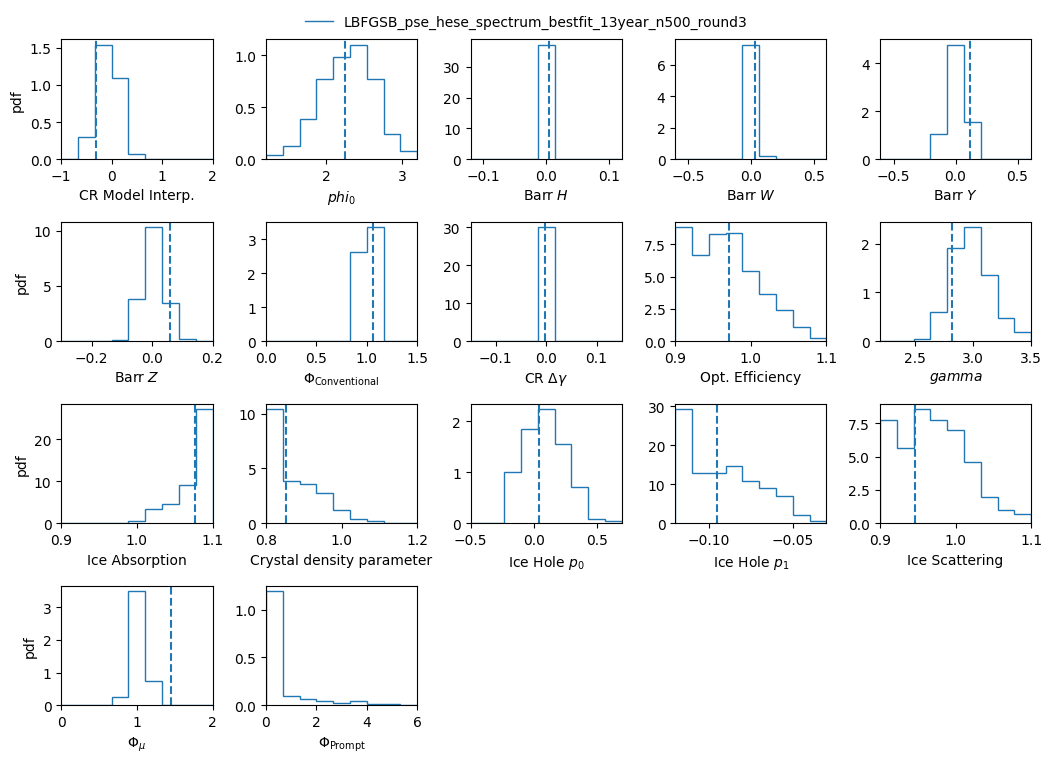

LBFGSB_pse_hese_spectrum_bestfit_13year_n500_seeded
['CR_grad', 'astro_norm', 'barr_h', 'barr_w', 'barr_y', 'barr_z', 'conv_norm', 'delta_gamma', 'dom_eff', 'gamma_astro', 'ice_abs', 'ice_crystal', 'ice_holep0', 'ice_holep1', 'ice_scat', 'muongun_norm', 'prompt_norm']


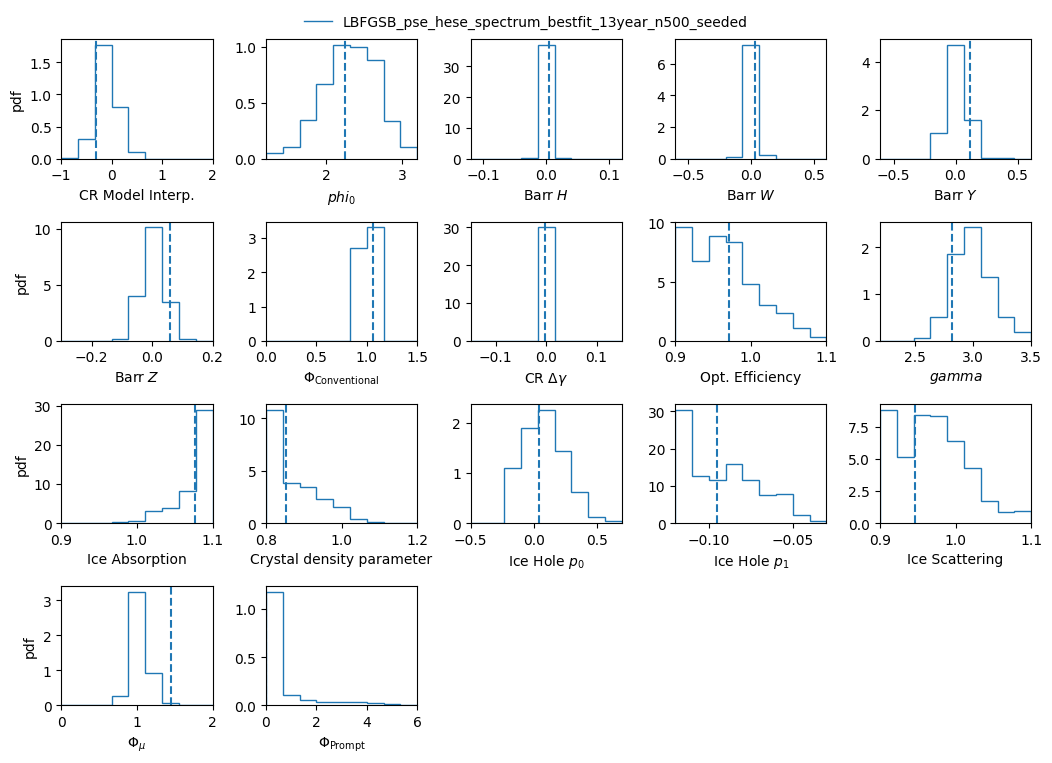

force_full_3_nlight_20_pse_hese_spectrum_bestfit_13year_n500_round3
['CR_grad', 'astro_norm', 'barr_h', 'barr_w', 'barr_y', 'barr_z', 'conv_norm', 'delta_gamma', 'dom_eff', 'gamma_astro', 'ice_abs', 'ice_crystal', 'ice_holep0', 'ice_holep1', 'ice_scat', 'muongun_norm', 'prompt_norm']


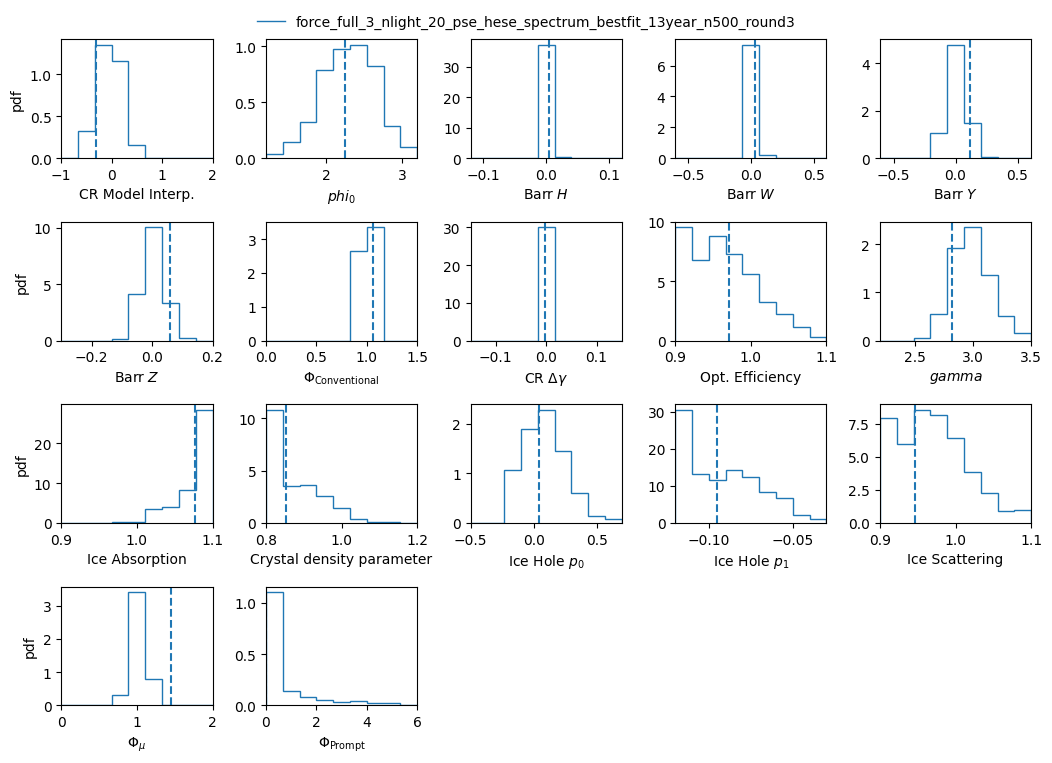

force_full_3_nlight_20_pse_hese_spectrum_bestfit_13year_n500_seeded
['CR_grad', 'astro_norm', 'barr_h', 'barr_w', 'barr_y', 'barr_z', 'conv_norm', 'delta_gamma', 'dom_eff', 'gamma_astro', 'ice_abs', 'ice_crystal', 'ice_holep0', 'ice_holep1', 'ice_scat', 'muongun_norm', 'prompt_norm']


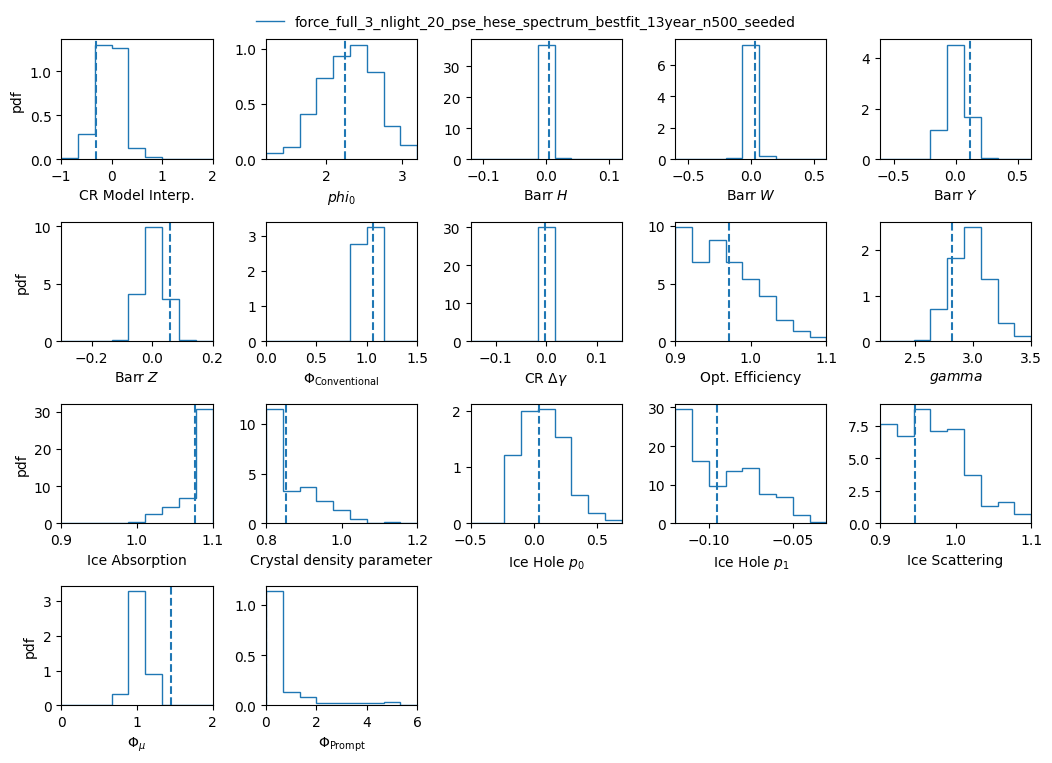

In [61]:
for combo in combos:
    print(combo[0])
    fig, handles, labels = scanplotter.plot_scan_matrix(
        scans_to_plot=combo,
        do_asimov=False,
        do_pseudoexp=True,
        # nbins=25,
        width_scale=1.9,
        height_scale=0.7,
        remove_peaks=False,
        default_ylims=False,
        plot_inject=True,
    )
    # labels = [format_label(label) for label in labels]
    # edit the hspace and wspaces between subplots:
    fig.subplots_adjust(hspace=0.25, wspace=0.3)
    plt.tight_layout()
    fig.legend(
        handles,
        labels,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.03),
        ncol=len(handles),
        frameon=False
    )
    # axes = fig.axes
    # axes[0].axvline(1.0, color='black', linestyle='--')
    # plt.savefig(
    #     f"/home/pfuerst/documentation/GalacticCombinedFit_wiki/plots/confusion/ice/DELETE.png",
    #     bbox_inches='tight'
    # )
    plt.show()

#### LLH Distributions

In [ ]:
dfs = {}

for name in names:
    ts = 2 * (
        scan_hdls[name].get_pseudoexp_df()["llh"] -
        scan_hdls[name].get_pseudoexp_df()["sat_llh"]
    )

    # add combined ts to df:
    dfs[name] = scan_hdls[name].get_pseudoexp_df()
    dfs[name]["combined_ts"] = ts

#### LLH bestfits

In [63]:
llh_info_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/philipp/saturated/force_full_3_nlight_20/"

hese_file = os.path.join(llh_info_dir, "SatLLH_nbestfit20_scan_astro_gamma_1D_10steps_round2.txt")


bestfit_llh_infos = {}
for name, file in zip(
    names, [hese_file for i in names]
):
    with open(file, "r") as f:
        llh_info = yaml.safe_load(f)
    print(llh_info)
    bestfit_ts = 2 * (llh_info["min LLH"] - llh_info["Saturated LLH"])
    if "Poisson" in name:
        # saturated llh is already substracted for Poisson
        bestfit_ts = 2 * llh_info["min LLH"]
    bestfit_llh_infos[name] = llh_info
    bestfit_llh_infos[name]['ts'] = bestfit_ts


{'Scan Path': '//data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step1_hese_flux/data_fits/force_full_3_nlight_20/nbestfit20_scan_astro_gamma_1D_10steps_round2', 'min LLH': 212.8606063267837, 'Saturated LLH': 90.96186371833632}
{'Scan Path': '//data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step1_hese_flux/data_fits/force_full_3_nlight_20/nbestfit20_scan_astro_gamma_1D_10steps_round2', 'min LLH': 212.8606063267837, 'Saturated LLH': 90.96186371833632}
{'Scan Path': '//data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step1_hese_flux/data_fits/force_full_3_nlight_20/nbestfit20_scan_astro_gamma_1D_10steps_round2', 'min LLH': 212.8606063267837, 'Saturated LLH': 90.96186371833632}
{'Scan Path': '//data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step1_hese_flux/data_fits/force_full_3_nlight_20/nbestfit20_scan_astro_gamm

### Chisq distributions

In [64]:
from scipy.stats import chi2

# 7 degrees for conventional
# conv_norm, delta_gamma, CR_grad, barr_h, barr_w, barr_z, barr_y
# 1 muongun norm
# 1 additional for prompt
# prompt_norm, delta_gamma, CR_grad
# 2 astro parameters
# gamma_astro, astro_norm
# total is 11

# get degrees of freedom.
hese_pars = 11

n_ebins_tracks = 23
n_zenbins_tracks = 10

n_ebins_cascades = 23
n_zenbins_cascades = 10

n_ebins_doubles = 13
n_bdt_doubles = 10

delta_dof_combined = (
    n_ebins_tracks * n_zenbins_tracks 
    + n_ebins_cascades * n_zenbins_cascades 
    + n_ebins_doubles * n_bdt_doubles 
    - hese_pars
)

print(f"HESE: {delta_dof_combined} dof")

HESE: 579 dof


In [65]:
# chisq distributions with the mention ndof, plot in a region  of 0 to 600
chisq_x = {
    "HESE": np.linspace(0, 300, 300),
}

chisq = {name: chi2.pdf(chisq_x["HESE"], df=delta_dof_combined) for name in names}

In [19]:
%matplotlib inline

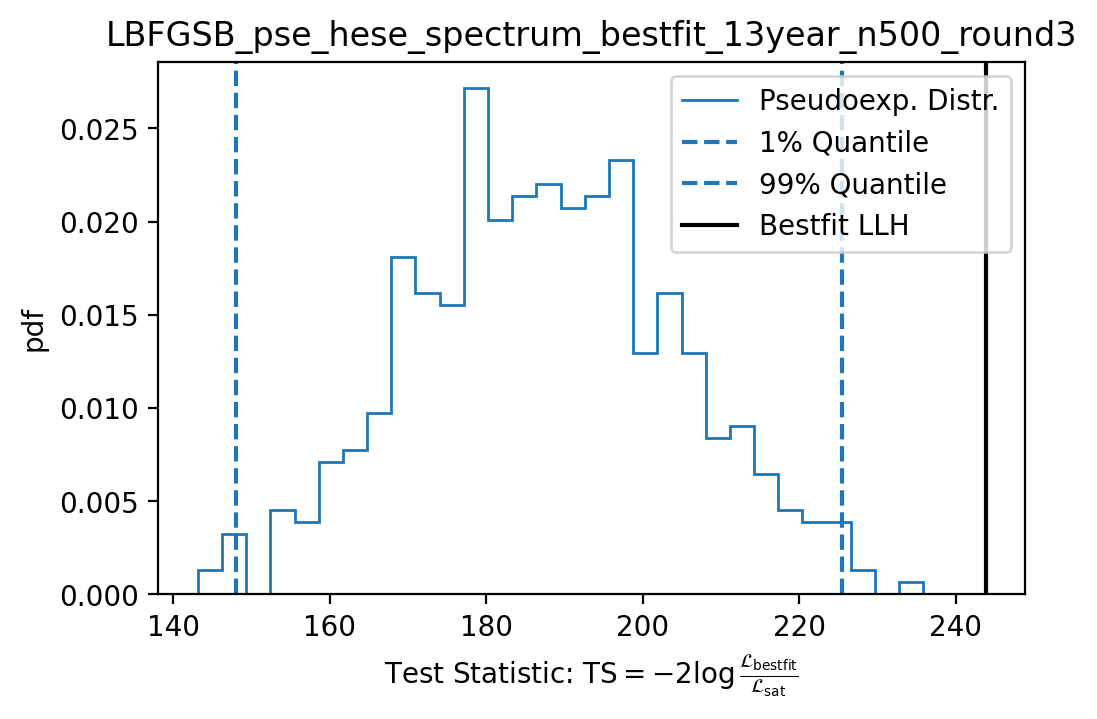

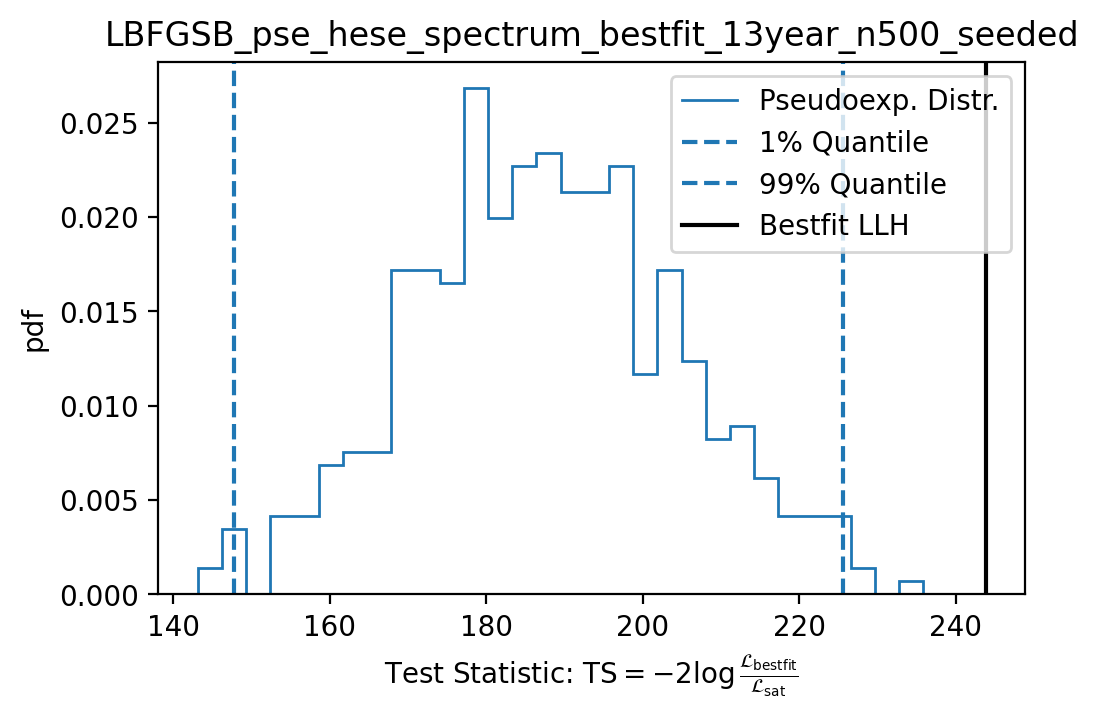

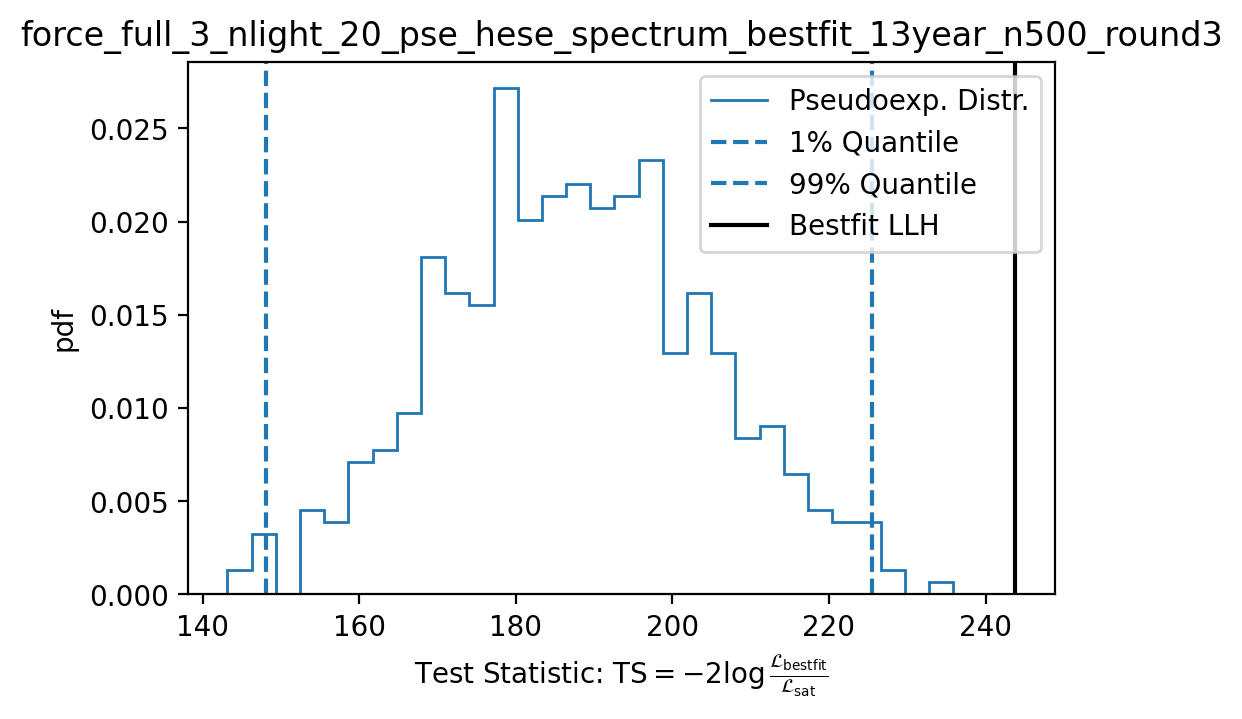

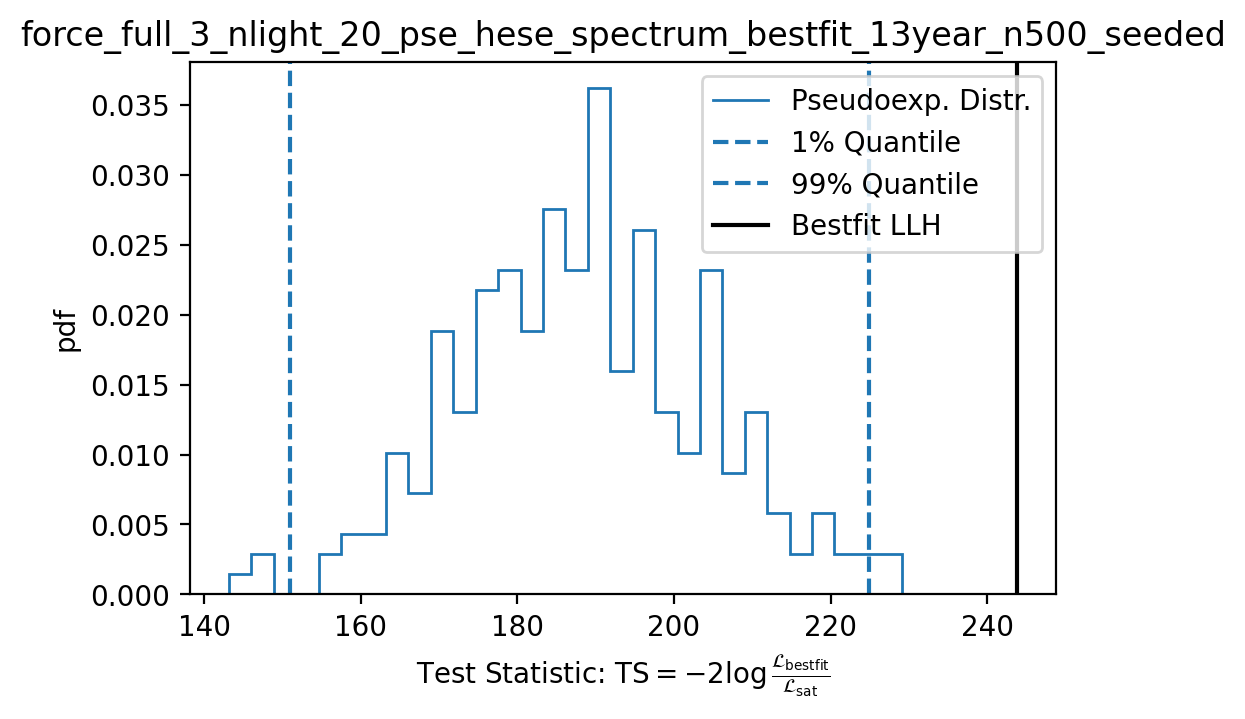

In [68]:
for name, title in zip(
    names,names
):
    pseudoexp_ts = dfs[name]["combined_ts"]
    fig, ax = SinglePlot().create(dpi=200)
    ax.set_title(title)
    quantiles = np.quantile(pseudoexp_ts, [0.01, 0.99])
    hist, bins = np.histogram(pseudoexp_ts, bins=30, density=True)

    ax.stairs(
        hist,
        bins,
        color=all_hdls[name]["pseudoexp_settings"]["color"],
        label="Pseudoexp. Distr."
    )

    # plot quantiles
    ax.axvline(
        quantiles[0],
        color=all_hdls[name]["pseudoexp_settings"]["color"],
        linestyle='--',
        label='1% Quantile'
    )
    ax.axvline(
        quantiles[1],
        color=all_hdls[name]["pseudoexp_settings"]["color"],
        linestyle='--',
        label='99% Quantile'
    )

    # plot bestfit llh
    ax.axvline(
        bestfit_llh_infos[name]["ts"],
        color="black",
        linestyle='-',
        label='Bestfit LLH'
    )
    if "Poisson" in name:
        plt.plot(
            chisq_x[name],
            chisq[name],
            color="grey",
            label=r"$\xi^2$ assuming Wilks"
        )

    ax.set_xlabel(
        r'Test Statistic: $\mathrm{TS} = -2\log \frac{\mathcal{L}_{\mathrm{bestfit}}}{\mathcal{L}_{\mathrm{sat}}}$'
    )
    ax.set_ylabel("pdf")
    plt.legend()
    # plt.savefig(
    #     os.path.join(
    #         "/home/home2/institut_3b/pfuerst/software/analysis/gp_globalfit_repo/GP_Globalfit_Analysis/unblinding/step0/plots/",
    #         f"GOF_SPL_Background_{name}.png"
    #     ),
    #     bbox_inches='tight'
    # )
    # plt.savefig(
    #     os.path.join(
    #         "/home/home2/institut_3b/pfuerst/software/analysis/gp_globalfit_repo/GP_Globalfit_Analysis/unblinding/step0/plots/",
    #         f"GOF_SPL_Background_{name}.pdf"
    #     ),
    #     bbox_inches='tight'
    # )